In [ ]:
# GENERAL LIBRARIES
import os
import numpy as np
import pandas as pd
import pennylane as qml
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report)
from torch.utils.data import WeightedRandomSampler


# TORCH MODULES
import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import Dataset, DataLoader

# Plot parameters
plt.rcParams.update({
    'lines.linewidth': 2,               # linewidth
    'mathtext.fontset': 'cm',           # math font
    'mathtext.default': 'it',           # math font style
    'font.size': 24,                    # font size
    'axes.titlesize': 24,               # title size
    'axes.grid': True,                  # grid
    'grid.linestyle': '-.',             # grid style
    'axes.facecolor': '#ECECEC',        # background color for the axes
    'figure.facecolor': '#FFFFFF',      # background color for the axes
    'legend.facecolor': '#FFFFFF'       # background color for the legend
})

/usr/local/lib/python3.12/dist-packages/pennylane/__init__.py:209: RuntimeWarning: PennyLane is not yet compatible with JAX versions > 0.6.2. You have version 0.7.2 installed. Please downgrade JAX to 0.6.2 to avoid runtime errors using python -m pip install jax~=0.6.0 jaxlib~=0.6.0
  warnings.warn(


Here, we define the global variables: device (cpu or CUDA), seed (for debugging), and the number of qubits (one for each feature, in our case, five qubits).

In [5]:
# GLOBAL VARIABLES
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(DEVICE)
SEED = 42
QUBITS = 5

cpu


In [6]:
# read in the data, mount it to the drive for google collab

from google.colab import drive
drive.mount('/content/drive')

# Change work directory
os.chdir("/content/drive/MyDrive/Colab Notebooks")

# test print
print(os.getcwd())
# print(os.listdir("neo.csv"))

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks


We upload the data we will use for the binary classification task. For that, we chose five numerical features `est_diameter_min`, `est_diameter_max`, `relative_velocity`, `miss_distance`, and `absolute_magnitude`. The target was the column `hazardous`.

In [7]:
# Data uploading
class NasaDataset(Dataset):
    def __init__(self, data, targets):
        self.data = data
        self.targets = targets

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        data = torch.tensor(self.data[index], dtype = torch.float32)
        targets = torch.tensor(self.targets[index], dtype = torch.float32)
        return data, targets

# Raw data
raw_data = pd.read_csv(r"neo.csv")

# Relevant features
feats = [
    "est_diameter_min",
    "est_diameter_max",
    "relative_velocity",
    "miss_distance",
    "absolute_magnitude",
]

data = raw_data[feats].values.astype(np.float32)
targets = raw_data["hazardous"].values.astype(np.float32)

Next, we split the data into training data, testing data, and validation data. For that, we used the modules provided by `sklearn`.

In [8]:
# Training data
data_tr, data_temp, targets_tr, targets_temp = train_test_split(
    data, targets, test_size = 0.3, random_state = SEED, stratify = targets)

# Validation and testing data
data_val, data_test, targets_val, targets_test = train_test_split(
    data_temp, targets_temp, test_size = 0.5, random_state = SEED, stratify = targets_temp)

# Scale data
scaler = StandardScaler()
data_tr = scaler.fit_transform(data_tr).astype(np.float32)
data_val = scaler.transform(data_val).astype(np.float32)
data_test = scaler.transform(data_test).astype(np.float32)

# Datasets
train_ds = NasaDataset(data_tr, targets_tr)
val_ds = NasaDataset(data_val, targets_val)
test_ds = NasaDataset(data_test, targets_test)

In [9]:
print(f"Dataset sizes:")
print(f"-  Train: {len(train_ds)} samples")
print(f"-  Val:   {len(val_ds)} samples")
print(f"-  Test:  {len(test_ds)} samples\n")

Dataset sizes:
-  Train: 63585 samples
-  Val:   13625 samples
-  Test:  13626 samples



In [10]:
# Create dataloaders
def create_dataloaders(batch_size: int = 32):
    train_loader = DataLoader(train_ds, batch_size = batch_size, shuffle = True)
    val_loader = DataLoader(val_ds, batch_size = batch_size, shuffle = False)
    test_loader = DataLoader(test_ds, batch_size = batch_size, shuffle = False)

    print(f"DataLoader info (batch_size = {batch_size}):")
    print(f"  - Train batches: {len(train_loader)}")
    print(f"  - Val batches:   {len(val_loader)}")
    print(f"  - Test batches:  {len(test_loader)}\n")

    return train_loader, val_loader, test_loader

In [11]:
def create_dataloaders(batch_size: int = 32):
    # =========================
    # Balanced sampler (50/50)
    # =========================
    targets = torch.tensor(train_ds.targets, dtype=torch.long)

    class_counts = torch.bincount(targets)
    class_weights = 1.0 / class_counts.float()
    sample_weights = class_weights[targets]

    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        sampler=sampler
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False
    )

    print(f"DataLoader info (batch_size = {batch_size}):")
    print(f"  - Train batches (balanced): {len(train_loader)}")
    print(f"  - Val batches:             {len(val_loader)}")
    print(f"  - Test batches:            {len(test_loader)}\n")

    return train_loader, val_loader, test_loader


In [12]:
train_loader, val_loader, test_loader = create_dataloaders(batch_size = 64)

DataLoader info (batch_size = 64):
  - Train batches (balanced): 994
  - Val batches:             213
  - Test batches:            213



Here, we construct the quantum neural network. For that, we recall that we want to learn a function
$$
f_{\boldsymbol{\theta}}(\vec{x}) = \langle 0 | \hat{U}^{\dagger}(\vec{x}) \hat{W}^{\dagger}(\boldsymbol{\theta}) \hat{O} \hat{W}(\boldsymbol{\theta}) \hat{U}(\vec{x}) | 0 \rangle
$$

that classifies a data point into one of two categories. Here, $\hat{U}(\vec{x})$ is a data encoding quantum circuit (or feature map) that maps the classical data into a quantum state. For our project, we used three different data encoding quantum circuits:
$$
\begin{align*}
%
\hat{U}_{1}(\vec{x}) &= \bigotimes_{i = 0}^{n - 1} \hat{R}_{y}(\vec{x}), \\
%
\hat{U}_{2}(\vec{x}) &= \bigotimes_{i = 0}^{n - 1} \hat{R}_{x}(\vec{x}) \hat{R}_{z}(\vec{x}), \\
%
\hat{U}_{3}(\vec{x}) &= \left[ \exp\left(\mathrm{i} \sum_{i = 1}^{d} x_{i} Z_{i} \right) \exp\left(\mathrm{i} \sum_{i = 1}^{d - 1} \sum_{j = i + 1}^{d} (\pi - x_{i}) (\pi - x_{j}) Z_{i} Z_{j} \right) \hat{H}^{\otimes 5}\right]^{r}.
\end{align*}
$$

Here, $\hat{R}$ represents a rotation gate, and $r$ is the number of repetions. We used $r = 2$, as the authors from the original paper did. Furthermore, we implemented three different ansatze:
$$
\begin{align*}
%
\hat{W}_{1}(\boldsymbol{\theta}) &= \left\lbrace \left[ \bigotimes_{i = 0}^{n - 2} \mathrm{CNOT}_{i, i + 1} \right] \left[ \bigotimes_{i = 0}^{n - 1} \hat{R}_{y}(\theta_{i}) \right] \right\rbrace^{L}, \\
%
\hat{W}_{2}(\boldsymbol{\theta}) &= \left\lbrace \left[ \bigotimes_{i = n - 2}^{0} \mathrm{CNOT}_{i, i + 1} \right] \left[ \bigotimes_{i = 0}^{n - 1} \hat{R}_{z}(\theta_{i}) \hat{R}_{x}(\theta_{i}) \right] \right\rbrace^{L},
\end{align*}
$$

$L$ represents the number of layers (that is, the number of repetitions of the same block of quantum gates).

In [13]:
# Feature maps or data encoding circuits
def feature_map_1(data, n_qubits, scale = 1.0):
    qml.AngleEmbedding(features = data * scale, wires = range(n_qubits), rotation = 'Y')

def feature_map_2(data, n_qubits, scale = 1.0):
    qml.AngleEmbedding(features = data * scale, wires = range(n_qubits), rotation = 'Z')
    qml.AngleEmbedding(features = data * scale, wires = range(n_qubits), rotation = 'X')

def feature_map_3(data, n_qubits, reps = 2):
    assert len(data) == n_qubits, f"Input size {len(data)} must match n_qubits {n_qubits}"
    for _ in range(reps):
        for index in range(n_qubits):
            qml.Hadamard(wires = index)

        for index in range(n_qubits):
            qml.RZ(2.0 * data[index], wires = index)

        for idx0 in range(n_qubits):
            for idx1 in range(idx0 + 1, n_qubits):
                qml.CNOT(wires = [idx0, idx1])
                qml.RZ(2.0 * data[idx0] * data[idx1], wires = idx1)
                qml.CNOT(wires = [idx0, idx1])

# Variational ansatze
def variational_ansatz_1(angle, n_qubits):
    n_layers, n_wires = angle.shape
    assert n_wires == n_qubits, f"Expected {n_qubits} wires, got {n_wires}"

    for layer in range(n_layers):
        for qubit in range(n_wires):
            qml.RY(phi=angle[layer, qubit], wires = qubit)
        for qubit in range(n_wires):
            qml.CNOT(wires = [qubit, (qubit + 1) % n_wires])

def variational_ansatz_2(angle, n_qubits):
    n_layers, n_wires = angle.shape
    assert n_wires == n_qubits, f"Expected {n_qubits} wires, got {n_wires}"

    for layer in range(n_layers):
        for qubit in range(n_wires):
            qml.RX(angle[layer, qubit], wires = qubit)
            qml.RZ(angle[layer, qubit], wires = qubit)
        for qubit in range(n_wires - 1, -1, -1):
            qml.CNOT(wires = [(qubit + 1) % n_wires, qubit])

def variational_ansatz_3(angle, n_qubits):
    n_layers, n_params = angle.shape
    assert n_params == 20, f"Each layer requires 20 parameters, got {n_params}"
    assert n_qubits == 5, "This ansatz is designed for 5 qubits"

    for layer in range(n_layers):
        idx = 0
        params = angle[layer]

        # First RY layer
        for qubit in range(n_qubits):
            qml.RY(params[idx], wires=qubit)
            idx += 1

        # CRZ: 4 -> 0
        qml.CRZ(params[idx], wires = [4, 0])
        idx += 1

        # CRZ chain
        crz_pairs_step3 = [(3, 4), (2, 3), (2, 1), (0, 1)]
        for control, target in crz_pairs_step3:
            qml.CRZ(params[idx], wires = [control, target])
            idx += 1

        # Second RY layer
        for qubit in range(n_qubits):
            qml.RY(params[idx], wires = qubit)
            idx += 1

        # Final CRZ layer
        crz_pairs_step5 = [(4, 3), (0, 4), (1, 0), (2, 1), (3, 2)]
        for control, target in crz_pairs_step5:
            qml.CRZ(params[idx], wires = [control, target])
            idx += 1

In [14]:
FEATURE_MAPS = {
    "fm1": feature_map_1,
    "fm2": feature_map_2,
    "fm3": feature_map_3}

ANSATZE = {
    "ansatz1": variational_ansatz_1,
    "ansatz2": variational_ansatz_2,
    "ansatz3": variational_ansatz_3}

In [15]:
class QNNClassifier(nn.Module):
    def __init__(self, angle_shape, feature_map_name = "fm1", ansatz_name = "ansatz1", n_qubits = QUBITS):
        super().__init__()
        self.angle = nn.Parameter(torch.randn(angle_shape, dtype = torch.float32) * 0.01)
        self.n_qubits = n_qubits

        dev = qml.device("lightning.qubit", wires = n_qubits)
        @qml.qnode(dev, interface = "torch", diff_method = "adjoint")
        def circuit(data, angle):
            feature_map = FEATURE_MAPS[feature_map_name]
            ansatz = ANSATZE[ansatz_name]

            if feature_map_name == "fm3" and data.ndim > 1:
                for _ in range(2):
                    for index in range(n_qubits):
                        qml.Hadamard(wires = index)
                    for index in range(n_qubits):
                        qml.RZ(2.0 * data[:, index], wires = index)
                    for idx0 in range(n_qubits):
                        for idx1 in range(idx0 + 1, n_qubits):
                            qml.CNOT(wires = [idx0, idx1])
                            qml.RZ(2.0 * data[:, idx0] * data[:, idx1], wires = idx1)
                            qml.CNOT(wires = [idx0, idx1])
            else:
                feature_map(data, n_qubits = n_qubits)
            ansatz(angle, n_qubits)
            return qml.expval(qml.PauliZ(0))
        self.circuit = circuit

    def forward(self, data):
        data = data.to(torch.float32)
        expvals = self.circuit(data, self.angle)
        probabilities = (expvals + torch.tensor(1.0, dtype = torch.float32)) / torch.tensor(2.0, dtype = torch.float32)

        if probabilities.ndim == 1:
            return probabilities.unsqueeze(1)
        return probabilities

In [16]:
# Training
def train_and_evaluate(qnn,
                       train_loader,
                       val_loader,
                       test_loader,
                       n_epochs = 50,
                       n_batches = None,
                       device = DEVICE,
                       learn_rate = 0.01,
                       feature_map_name = "fm1",
                       ansatz_name = "ansatz1"):

    qnn = qnn.to(device)
    optimizer = torch.optim.Adam(qnn.parameters(), lr = learn_rate)
    loss_function = nn.BCELoss()

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []}

    # Determine batches per epoch
    total_train_batches = len(train_loader)
    batches_per_epoch = n_batches if n_batches is not None else total_train_batches

    print(f"Training Configuration:")
    print(f"  1. Feature map: {feature_map_name}")
    print(f"  2. Ansatz: {ansatz_name}")
    print(f"  3. Learning rate: {learn_rate}")
    print(f"  4. Device: {device}")
    print(f"  5. Total train batches available: {total_train_batches}")
    print(f"  6. Batches per epoch: {batches_per_epoch}")
    print(f"  7. Epochs: {n_epochs}\n")

    # Training loop
    for epoch in range(n_epochs):
        # TRAINING PHASE
        qnn.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        # Progress bar for training
        pbar = tqdm(enumerate(train_loader),
                   total = batches_per_epoch,
                   desc = f"Epoch {epoch + 1}/{n_epochs} [Train]",
                   leave = True)

        for batch_idx, (data, targets) in pbar:
            if batch_idx >= batches_per_epoch:
                break

            data, targets = data.to(device), targets.to(device)
            targets = targets.to(torch.float32).unsqueeze(1)

            optimizer.zero_grad()
            outputs = qnn(data)
            loss = loss_function(outputs, targets)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            predictions = (outputs > 0.5).float()
            train_correct += (predictions == targets).sum().item()
            train_total += targets.size(0)

            # Update progress bar
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100.0 * train_correct / train_total:.2f}%'
            })

        pbar.close()

        # VALIDATION PHASE
        qnn.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for data, targets in tqdm(val_loader,
                                       desc = f"Epoch {epoch + 1}/{n_epochs} [Val]  ",
                                       leave = True):
                data, targets = data.to(device), targets.to(device)
                targets = targets.to(torch.float32).unsqueeze(1)

                outputs = qnn(data)
                loss = loss_function(outputs, targets)

                val_loss += loss.item()
                predictions = (outputs > 0.5).float()
                val_correct += (predictions == targets).sum().item()
                val_total += targets.size(0)

        # Epoch metrics
        avg_train_loss = train_loss / batches_per_epoch
        avg_val_loss = val_loss / len(val_loader)
        train_accuracy = 100.0 * train_correct / train_total
        val_accuracy = 100.0 * val_correct / val_total

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["train_acc"].append(train_accuracy)
        history["val_acc"].append(val_accuracy)

        # Epoch summary
        print(f"Epoch {epoch+1}/{n_epochs}: "
              f"Train Loss = {avg_train_loss:.4f}, Train Acc = {train_accuracy:.2f}% | "
              f"Val Loss = {avg_val_loss:.4f}, Val Acc = {val_accuracy:.2f}%")

    # TESTING PHASE
    print("\n" + "="*70)
    print("TESTING PHASE")
    print("="*70)

    qnn.eval()
    test_loss = 0.0
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for data, targets in tqdm(test_loader, desc = "Testing"):
            data, targets = data.to(device), targets.to(device)
            targets = targets.unsqueeze(1)

            outputs = qnn(data)
            loss = loss_function(outputs, targets)

            test_loss += loss.item()
            predictions = (outputs > 0.5).float()
            all_predictions.extend(predictions.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    avg_test_loss = test_loss / len(test_loader)
    all_predictions = np.array(all_predictions).flatten()
    all_targets = np.array(all_targets).flatten()
    test_accuracy = accuracy_score(all_targets, all_predictions)

    print(f"\nTest Loss: {avg_test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
    print("\nClassification Report:")
    print(classification_report(all_targets, all_predictions,
                                target_names = ["Not Hazardous", "Hazardous"]))
    print("\nConfusion Matrix:")
    confusion_mtrx = confusion_matrix(all_targets, all_predictions)
    print(confusion_mtrx)
    disp = ConfusionMatrixDisplay(confusion_matrix = confusion_mtrx, display_labels = [0, 1])
    disp.plot(cmap = "Blues")

    # try to get percentages too for easier understanding
    cm_percent = confusion_mtrx / confusion_mtrx.sum(axis=1, keepdims=True)
    print(np.round(cm_percent * 100, 2))
    cm_percent = np.round(cm_percent, 2)
    disp = ConfusionMatrixDisplay(confusion_matrix = cm_percent, display_labels = [0, 1])
    disp.plot(cmap = "Blues")

    return history, avg_test_loss, test_accuracy

def plot_training_history(history, feature_map_name = "fm1", ansatz_name = "ansatz1"):
    fig, axes = plt.subplots(1, 2, figsize = (18, 8))

    # Plot loss
    axes[0].plot(history["train_loss"], label = "Training loss", linewidth = 2, color = "#D40000")
    axes[0].plot(history["val_loss"], label = "Validation loss", linewidth = 2, color = "#0055AA")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    # Plot accuracy
    axes[1].plot(history["train_acc"], label = "Training accuracy", linewidth = 2, color = "#D40000")
    axes[1].plot(history["val_acc"], label = "Validation accuracy", linewidth = 2, color = "#0055AA")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f'training_history_{feature_map_name}_{ansatz_name}.pdf', dpi = 300)

In [17]:
def run_experiment(feature_map_name = "fm1",
                   ansatz_name = "ansatz1",
                   layers = 2,
                   n_epochs = 50,
                   n_batches = None,
                   batch_size = 32,
                   learn_rate = 0.01):

    # Create dataloaders with specified batch size
    train_loader, val_loader, test_loader = create_dataloaders(batch_size = batch_size)

    # Determine configuration
    if ansatz_name == "ansatz3":
        angle_shape = (layers, 20)
        n_qubits = 5
        print(f"Using ansatz3: 5 qubits, 20 parameters per layer")
    else:
        angle_shape = (layers, QUBITS)
        n_qubits = QUBITS

    print(f"Model: {layers} layer(s), angle_shape = {angle_shape}\n")

    # Create QNN
    qnn = QNNClassifier(
        angle_shape = angle_shape,
        feature_map_name = feature_map_name,
        ansatz_name = ansatz_name,
        n_qubits = n_qubits
    )

    # Train, validate, and test
    history, test_loss, test_acc = train_and_evaluate(
        qnn = qnn,
        train_loader = train_loader,
        val_loader = val_loader,
        test_loader = test_loader,
        n_epochs = n_epochs,
        n_batches = n_batches,
        device = DEVICE,
        learn_rate = learn_rate,
        feature_map_name = feature_map_name,
        ansatz_name = ansatz_name
    )

    # Plot results
    plot_training_history(history, feature_map_name, ansatz_name)
    return qnn, history, test_loss, test_acc

## Feature Map 1, Anzatz 1

DataLoader info (batch_size = 32):
  - Train batches (balanced): 1988
  - Val batches:             426
  - Test batches:            426

Model: 2 layer(s), angle_shape = (2, 5)

Training Configuration:
  1. Feature map: fm1
  2. Ansatz: ansatz1
  3. Learning rate: 0.001
  4. Device: cuda
  5. Total train batches available: 1988
  6. Batches per epoch: 64
  7. Epochs: 40



Epoch 1/40 [Val]  : 100%|██████████| 426/426 [00:33<00:00, 12.68it/s]


Epoch 1/40: Train Loss = 1.0395, Train Acc = 44.53% | Val Loss = 1.4153, Val Acc = 20.77%


Epoch 2/40 [Val]  : 100%|██████████| 426/426 [00:33<00:00, 12.72it/s]


Epoch 2/40: Train Loss = 1.0132, Train Acc = 44.24% | Val Loss = 1.3342, Val Acc = 21.75%


...

Epoch 39/40: Train Loss = 0.5485, Train Acc = 78.66% | Val Loss = 0.5446, Val Acc = 78.33%


Epoch 40/40 [Val]  : 100%|██████████| 426/426 [00:33<00:00, 12.76it/s]


Epoch 40/40: Train Loss = 0.5518, Train Acc = 78.96% | Val Loss = 0.5423, Val Acc = 78.25%

TESTING PHASE


Testing: 100%|██████████| 426/426 [00:34<00:00, 12.25it/s]



Test Loss: 0.5417
Test Accuracy: 0.7831 (78.31%)

Classification Report:
               precision    recall  f1-score   support

Not Hazardous       0.97      0.78      0.87     12300
    Hazardous       0.28      0.78      0.41      1326

     accuracy                           0.78     13626
    macro avg       0.62      0.78      0.64     13626
 weighted avg       0.90      0.78      0.82     13626


Confusion Matrix:
[[9643 2657]
 [ 298 1028]]
[[78.4  21.6 ]
 [22.47 77.53]]


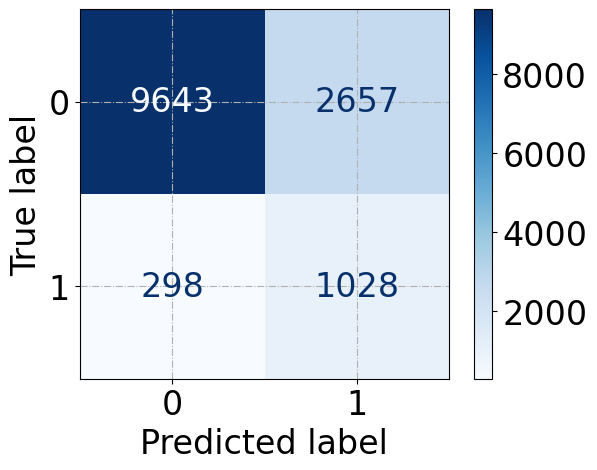

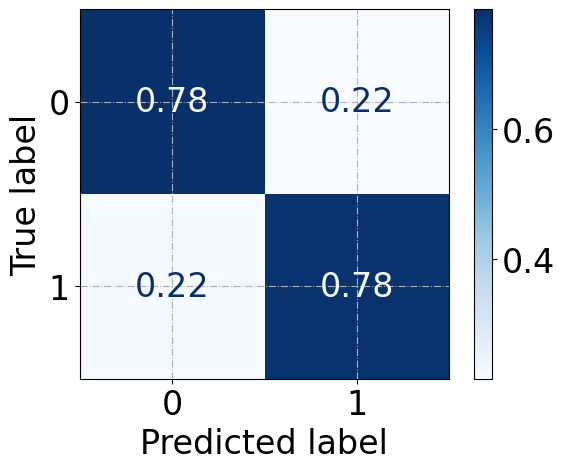

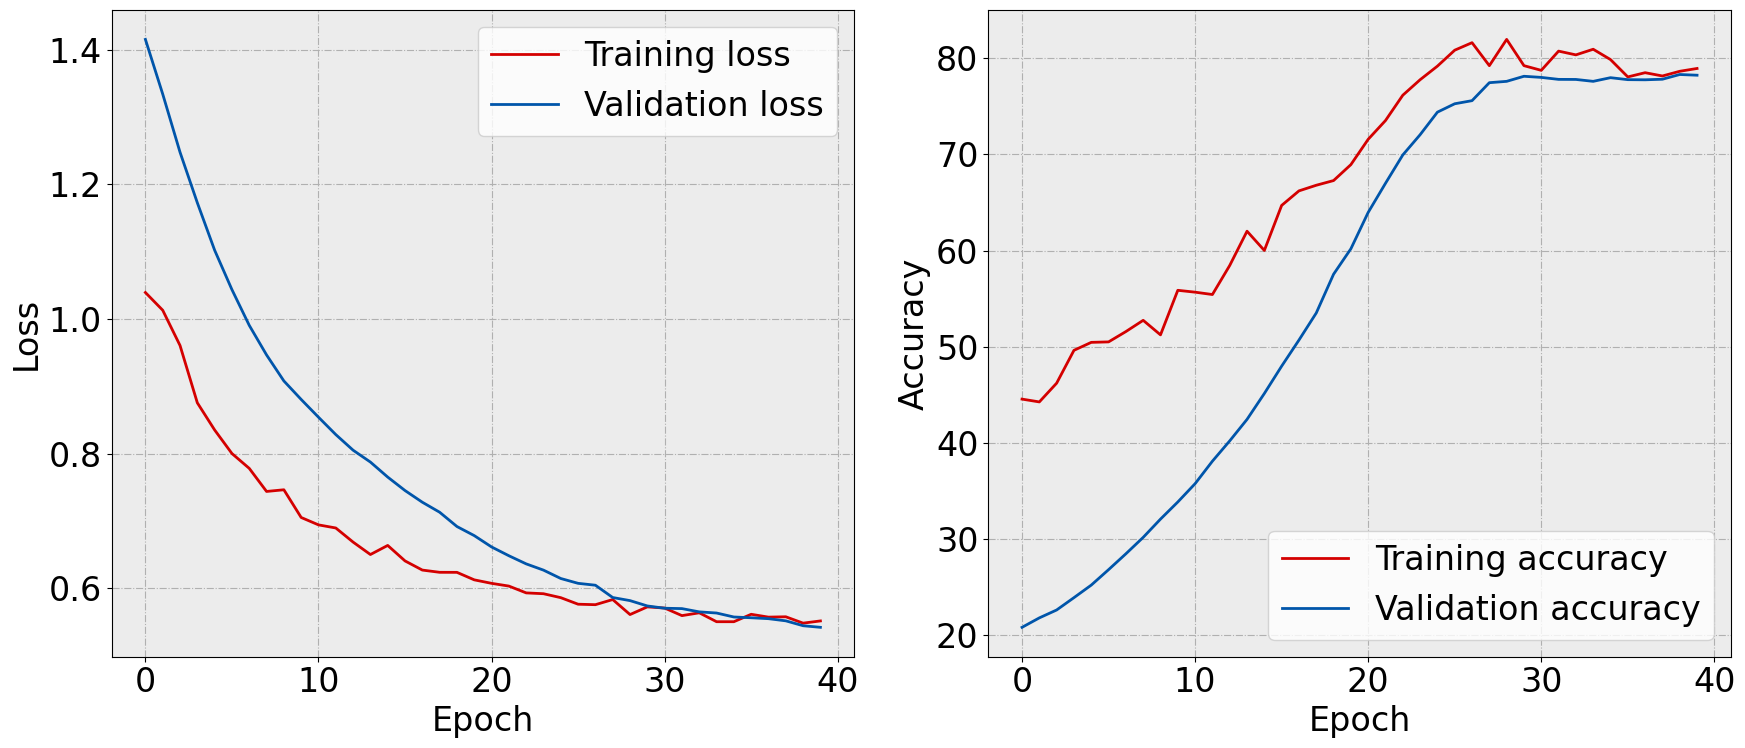

In [ ]:
qnn_1_2layers, history_1_2layers, test_loss_1_2layers, test_acc_1_2layers = run_experiment(
        feature_map_name = "fm1",
        ansatz_name = "ansatz1",
        layers = 2,
        n_epochs = 40,
        n_batches = 64,
        batch_size = 32,
        learn_rate = 0.001)

DataLoader info (batch_size = 32):
  - Train batches (balanced): 1988
  - Val batches:             426
  - Test batches:            426

Model: 3 layer(s), angle_shape = (3, 5)

Training Configuration:
  1. Feature map: fm1
  2. Ansatz: ansatz1
  3. Learning rate: 0.001
  4. Device: cuda
  5. Total train batches available: 1988
  6. Batches per epoch: 64
  7. Epochs: 40



Epoch 1/40 [Val]  : 100%|██████████| 426/426 [00:42<00:00,  9.92it/s]


Epoch 1/40: Train Loss = 0.9596, Train Acc = 47.95% | Val Loss = 1.2776, Val Acc = 24.46%


Epoch 2/40 [Val]  : 100%|██████████| 426/426 [00:43<00:00,  9.87it/s]


Epoch 2/40: Train Loss = 0.8580, Train Acc = 52.88% | Val Loss = 1.2024, Val Acc = 26.83%


...

Epoch 39/40: Train Loss = 0.4384, Train Acc = 83.84% | Val Loss = 0.4638, Val Acc = 76.73%


Epoch 40/40 [Val]  : 100%|██████████| 426/426 [00:43<00:00,  9.87it/s]


Epoch 40/40: Train Loss = 0.4542, Train Acc = 83.25% | Val Loss = 0.4638, Val Acc = 76.73%

TESTING PHASE


Testing: 100%|██████████| 426/426 [00:42<00:00, 10.06it/s]



Test Loss: 0.4688
Test Accuracy: 0.7641 (76.41%)

Classification Report:
               precision    recall  f1-score   support

Not Hazardous       0.99      0.75      0.85     12300
    Hazardous       0.28      0.94      0.44      1326

     accuracy                           0.76     13626
    macro avg       0.64      0.84      0.64     13626
 weighted avg       0.92      0.76      0.81     13626


Confusion Matrix:
[[9171 3129]
 [  85 1241]]
[[74.56 25.44]
 [ 6.41 93.59]]


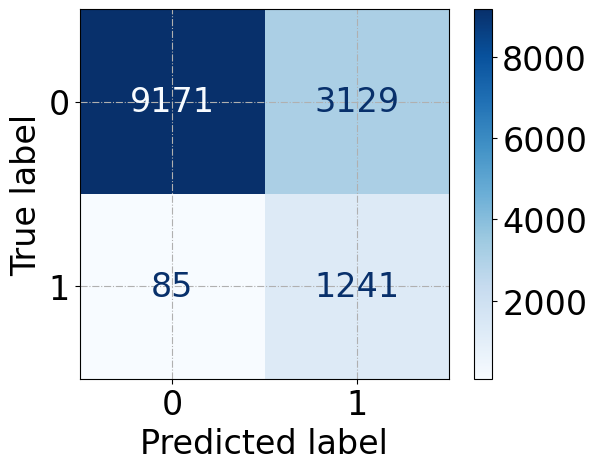

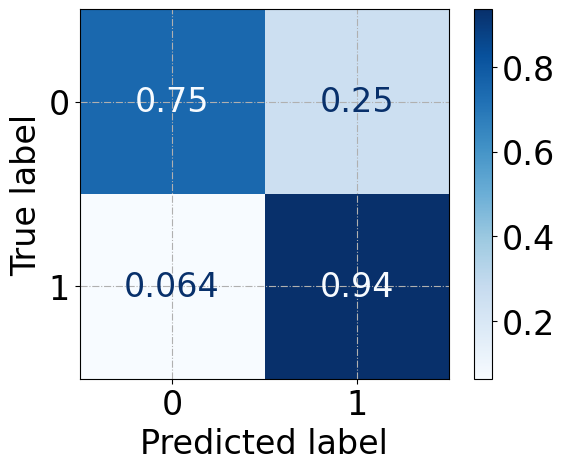

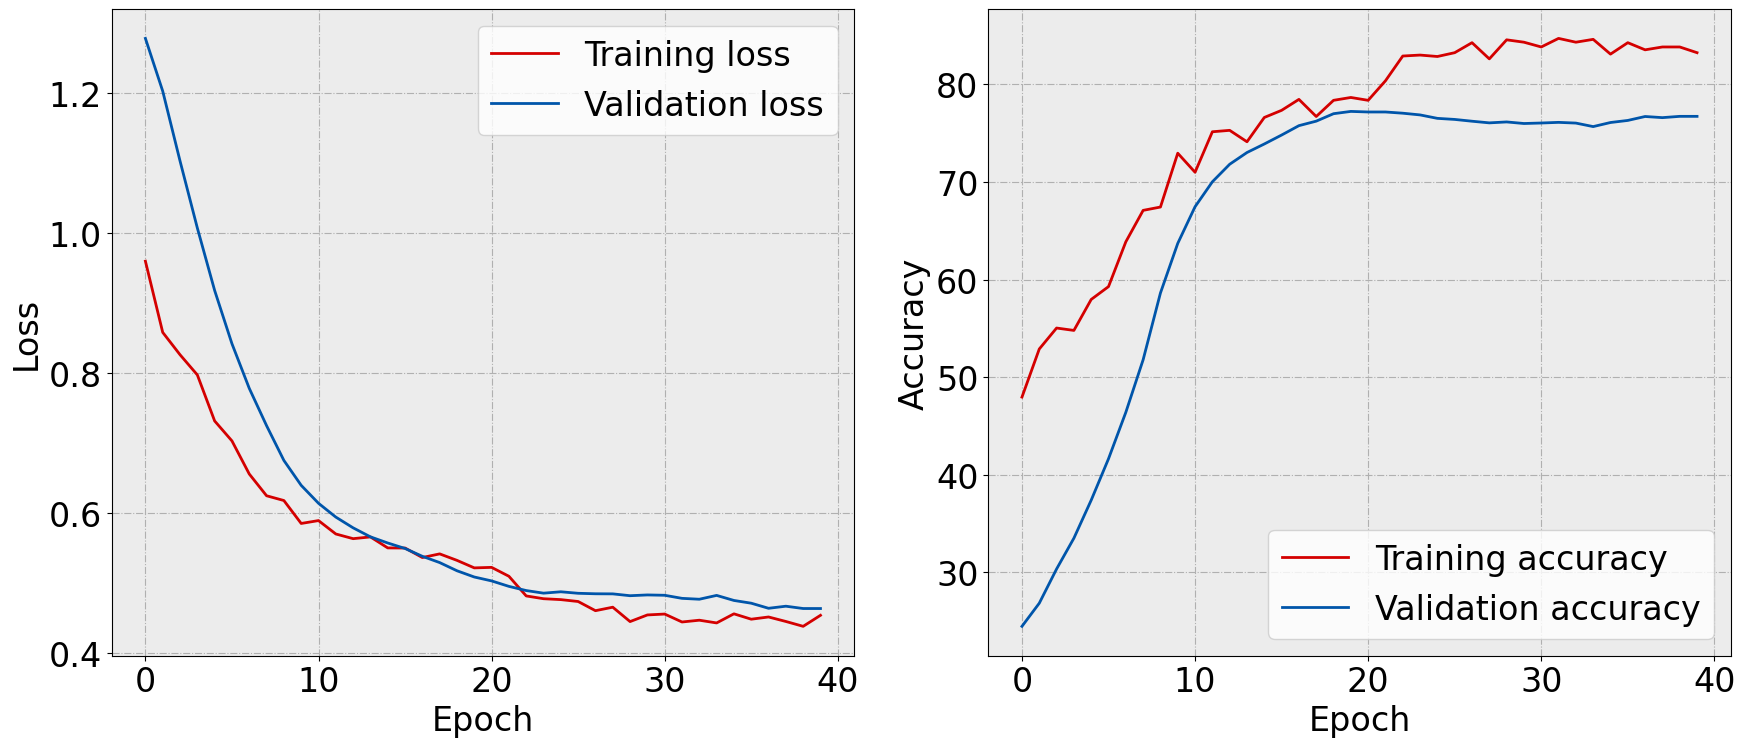

In [ ]:
qnn_1_3layers, history_1_3layers, test_loss_1_3layers, test_acc_1_3layers = run_experiment(
        feature_map_name = "fm1",
        ansatz_name = "ansatz1",
        layers = 3,
        n_epochs = 40,
        n_batches = 64,
        batch_size = 32,
        learn_rate = 0.001)

## Feature Map 1, Anzatz 2

DataLoader info (batch_size = 32):
  - Train batches (balanced): 1988
  - Val batches:             426
  - Test batches:            426

Model: 2 layer(s), angle_shape = (2, 5)

Training Configuration:
  1. Feature map: fm1
  2. Ansatz: ansatz2
  3. Learning rate: 0.001
  4. Device: cuda
  5. Total train batches available: 1988
  6. Batches per epoch: 64
  7. Epochs: 40



Epoch 1/40 [Val]  : 100%|██████████| 426/426 [00:47<00:00,  9.04it/s]


Epoch 1/40: Train Loss = 1.0593, Train Acc = 51.71% | Val Loss = 1.6574, Val Acc = 17.34%


Epoch 2/40 [Val]  : 100%|██████████| 426/426 [00:46<00:00,  9.22it/s]


Epoch 2/40: Train Loss = 1.0469, Train Acc = 48.83% | Val Loss = 1.5355, Val Acc = 16.81%


...

Epoch 39/40: Train Loss = 0.6087, Train Acc = 73.93% | Val Loss = 0.5841, Val Acc = 67.63%


Epoch 40/40 [Val]  : 100%|██████████| 426/426 [00:47<00:00,  9.06it/s]


Epoch 40/40: Train Loss = 0.6119, Train Acc = 74.76% | Val Loss = 0.5820, Val Acc = 68.32%

TESTING PHASE


Testing: 100%|██████████| 426/426 [00:45<00:00,  9.43it/s]



Test Loss: 0.5837
Test Accuracy: 0.6830 (68.30%)

Classification Report:
               precision    recall  f1-score   support

Not Hazardous       0.97      0.67      0.79     12300
    Hazardous       0.21      0.79      0.33      1326

     accuracy                           0.68     13626
    macro avg       0.59      0.73      0.56     13626
 weighted avg       0.89      0.68      0.75     13626


Confusion Matrix:
[[8259 4041]
 [ 279 1047]]
[[67.15 32.85]
 [21.04 78.96]]


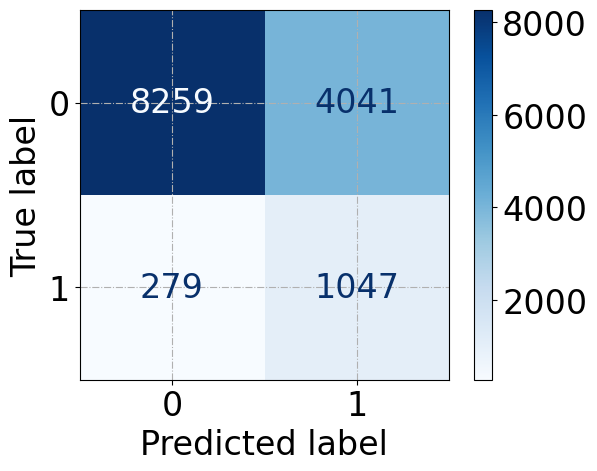

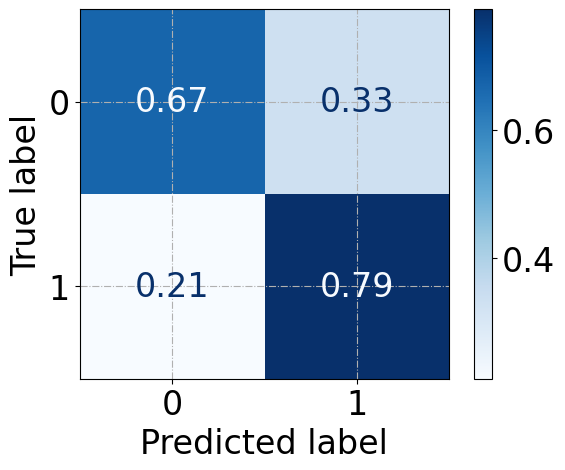

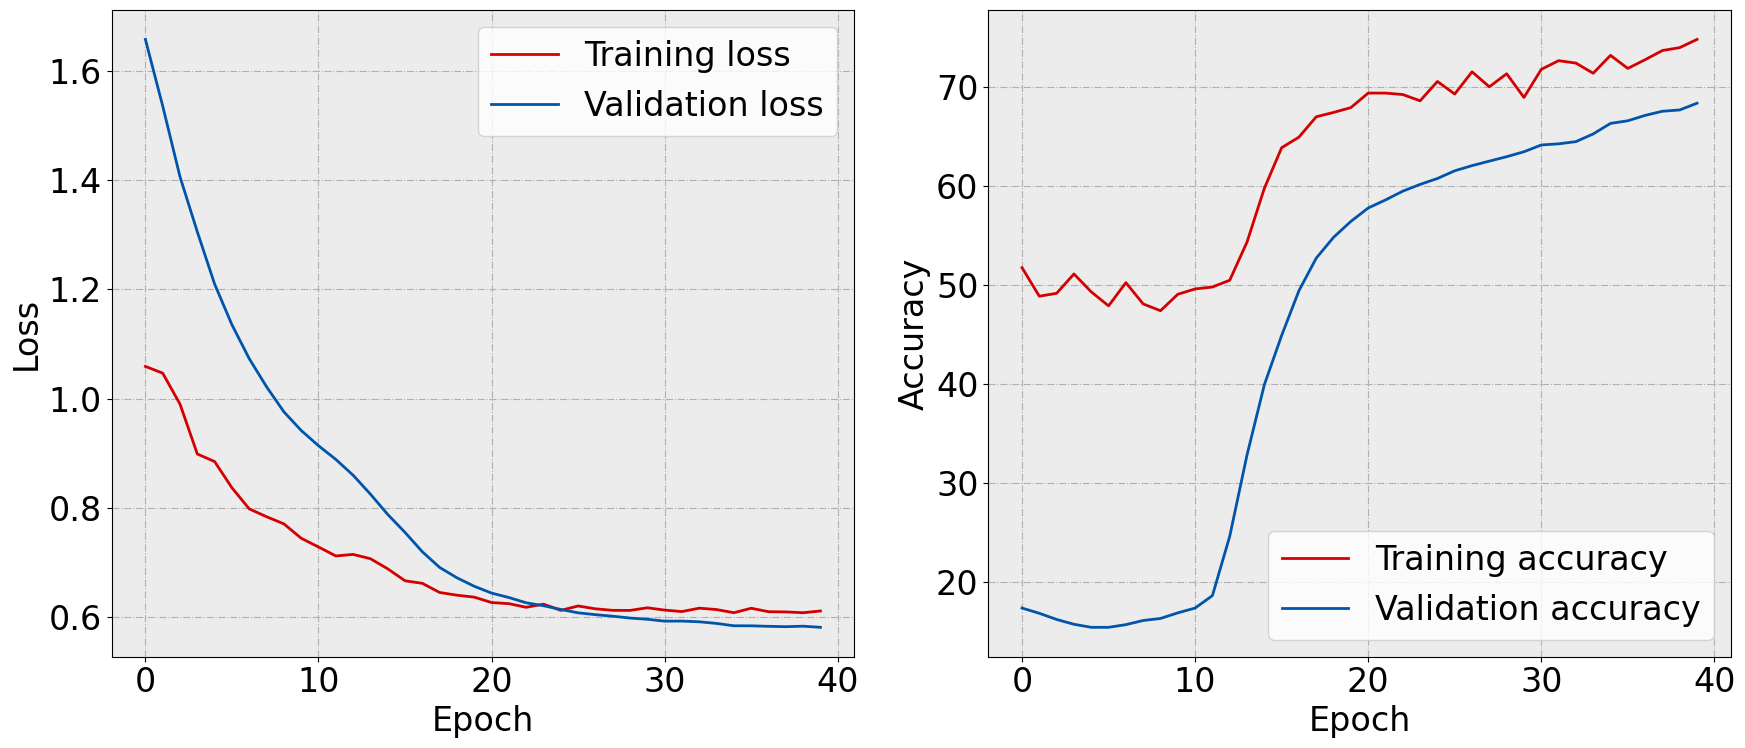

In [ ]:
qnn_2_2layers, history_2_2layers, test_loss_2_2layers, test_acc_2_2layers = run_experiment(
        feature_map_name = "fm1",
        ansatz_name = "ansatz2",
        layers = 2,
        n_epochs = 40,
        n_batches = 64,
        batch_size = 32,
        learn_rate = 0.001)

DataLoader info (batch_size = 32):
  - Train batches (balanced): 1988
  - Val batches:             426
  - Test batches:            426

Model: 3 layer(s), angle_shape = (3, 5)

Training Configuration:
  1. Feature map: fm1
  2. Ansatz: ansatz2
  3. Learning rate: 0.001
  4. Device: cuda
  5. Total train batches available: 1988
  6. Batches per epoch: 64
  7. Epochs: 40



Epoch 1/40 [Val]  : 100%|██████████| 426/426 [01:01<00:00,  6.97it/s]


Epoch 1/40: Train Loss = 1.2360, Train Acc = 44.09% | Val Loss = 1.8453, Val Acc = 15.19%


Epoch 2/40 [Val]  : 100%|██████████| 426/426 [01:03<00:00,  6.68it/s]


Epoch 2/40: Train Loss = 1.1884, Train Acc = 43.21% | Val Loss = 1.6560, Val Acc = 15.19%


...

Epoch 39/40: Train Loss = 0.4706, Train Acc = 84.13% | Val Loss = 0.5541, Val Acc = 72.12%


Epoch 40/40 [Val]  : 100%|██████████| 426/426 [01:02<00:00,  6.77it/s]


Epoch 40/40: Train Loss = 0.4878, Train Acc = 83.25% | Val Loss = 0.5557, Val Acc = 72.07%

TESTING PHASE


Testing: 100%|██████████| 426/426 [01:01<00:00,  6.95it/s]



Test Loss: 0.5595
Test Accuracy: 0.7184 (71.84%)

Classification Report:
               precision    recall  f1-score   support

Not Hazardous       1.00      0.69      0.82     12300
    Hazardous       0.26      1.00      0.41      1326

     accuracy                           0.72     13626
    macro avg       0.63      0.84      0.61     13626
 weighted avg       0.93      0.72      0.78     13626


Confusion Matrix:
[[8466 3834]
 [   3 1323]]
[[68.83 31.17]
 [ 0.23 99.77]]


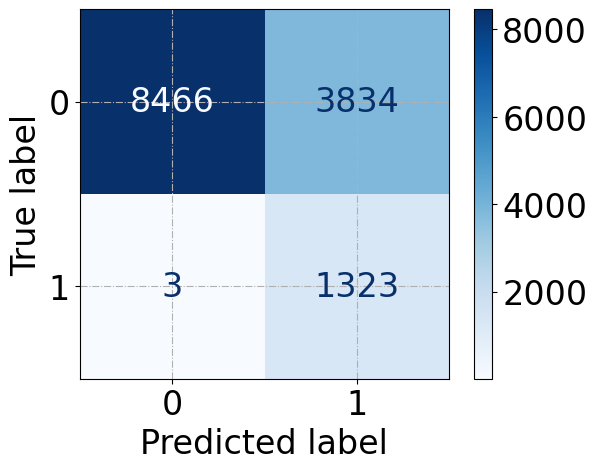

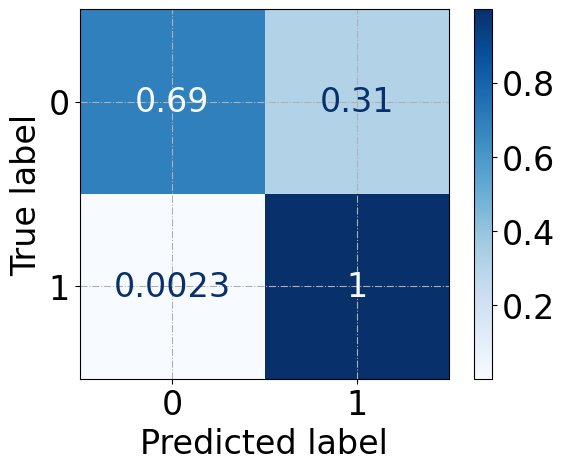

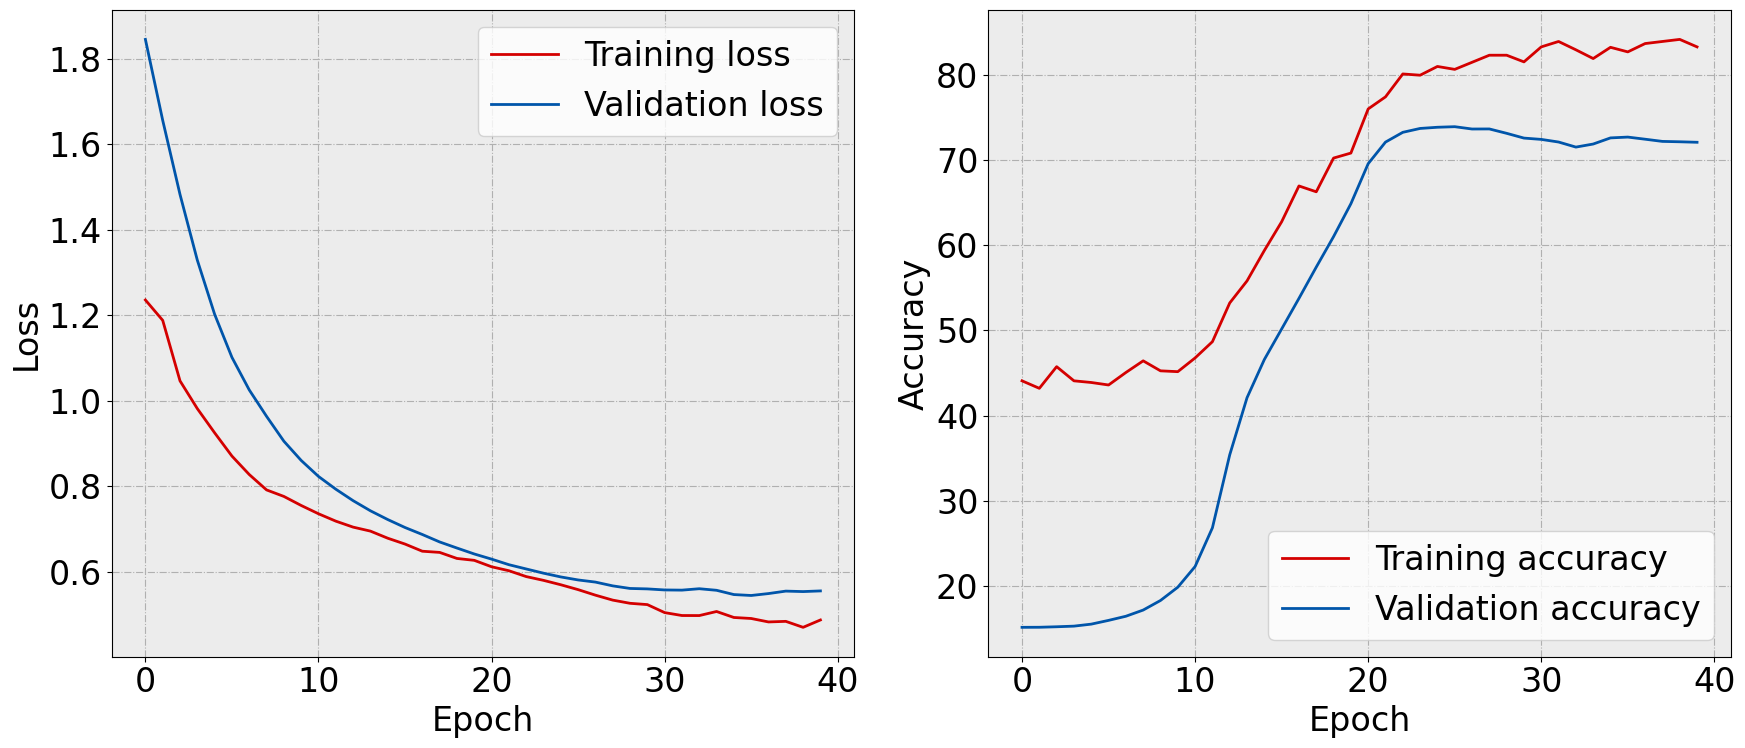

In [ ]:
qnn_2_3layers, history_2_3layers, test_loss_2_3layers, test_acc_2_3layers = run_experiment(
        feature_map_name = "fm1",
        ansatz_name = "ansatz2",
        layers = 3,
        n_epochs = 40,
        n_batches = 64,
        batch_size = 32,
        learn_rate = 0.001)

## Feature Map 2, Anzatz 1

DataLoader info (batch_size = 32):
  - Train batches (balanced): 1988
  - Val batches:             426
  - Test batches:            426

Model: 2 layer(s), angle_shape = (2, 5)

Training Configuration:
  1. Feature map: fm2
  2. Ansatz: ansatz1
  3. Learning rate: 0.001
  4. Device: cpu
  5. Total train batches available: 1988
  6. Batches per epoch: 64
  7. Epochs: 40



Epoch 1/40 [Val]  : 100%|██████████| 426/426 [00:43<00:00,  9.87it/s]


Epoch 1/40: Train Loss = 0.9996, Train Acc = 46.44% | Val Loss = 1.4423, Val Acc = 20.83%


Epoch 2/40 [Val]  : 100%|██████████| 426/426 [00:43<00:00,  9.71it/s]


Epoch 2/40: Train Loss = 1.0368, Train Acc = 44.68% | Val Loss = 1.3623, Val Acc = 21.51%


...

Epoch 39/40: Train Loss = 0.6854, Train Acc = 53.56% | Val Loss = 0.6349, Val Acc = 71.59%


Epoch 40/40 [Val]  : 100%|██████████| 426/426 [00:42<00:00,  9.94it/s]


Epoch 40/40: Train Loss = 0.6856, Train Acc = 53.27% | Val Loss = 0.6354, Val Acc = 71.47%

TESTING PHASE


Testing: 100%|██████████| 426/426 [00:42<00:00,  9.92it/s]



Test Loss: 0.6364
Test Accuracy: 0.7105 (71.05%)

Classification Report:
               precision    recall  f1-score   support

Not Hazardous       0.91      0.75      0.82     12300
    Hazardous       0.12      0.30      0.17      1326

     accuracy                           0.71     13626
    macro avg       0.51      0.53      0.50     13626
 weighted avg       0.83      0.71      0.76     13626


Confusion Matrix:
[[9278 3022]
 [ 923  403]]
[[75.43 24.57]
 [69.61 30.39]]


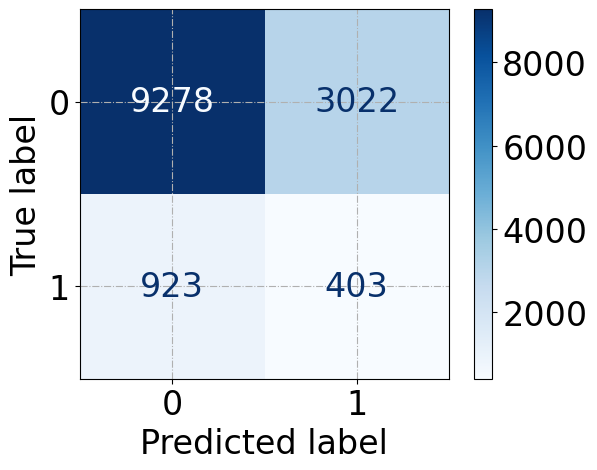

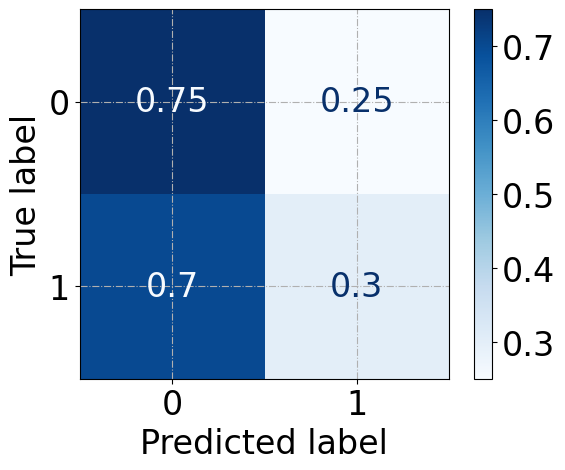

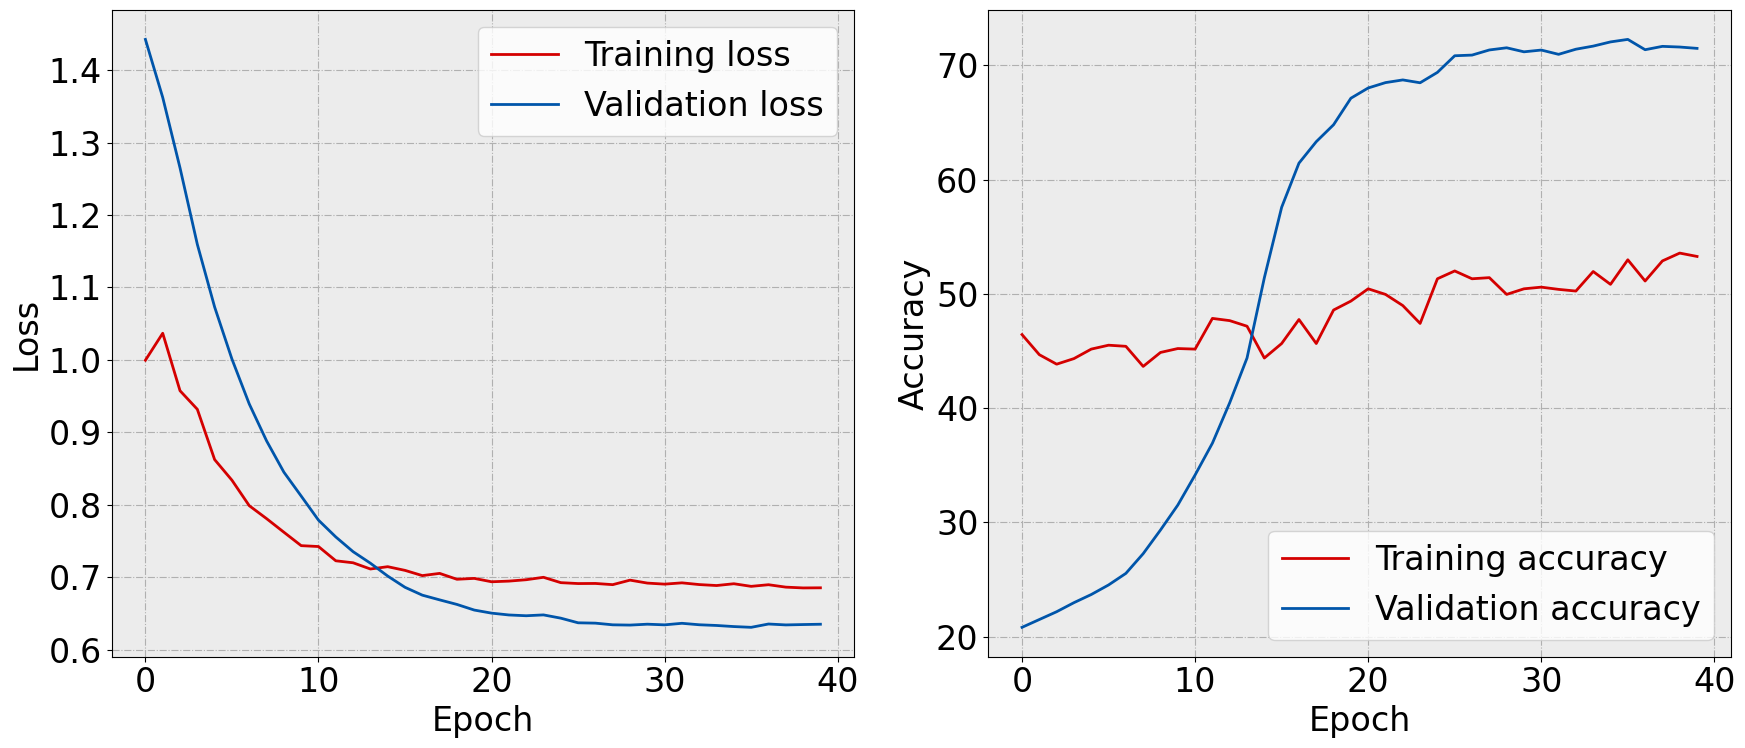

In [18]:
qnn_3_2layers, history_3_2layers, test_loss_3_2layers, test_acc_3_2layers = run_experiment(
        feature_map_name = "fm2",
        ansatz_name = "ansatz1",
        layers = 2,
        n_epochs = 40,
        n_batches = 64,
        batch_size = 32,
        learn_rate = 0.001)

DataLoader info (batch_size = 32):
  - Train batches (balanced): 1988
  - Val batches:             426
  - Test batches:            426

Model: 3 layer(s), angle_shape = (3, 5)

Training Configuration:
  1. Feature map: fm2
  2. Ansatz: ansatz1
  3. Learning rate: 0.001
  4. Device: cpu
  5. Total train batches available: 1988
  6. Batches per epoch: 64
  7. Epochs: 40



Epoch 1/40 [Val]  : 100%|██████████| 426/426 [00:54<00:00,  7.89it/s]


Epoch 1/40: Train Loss = 0.9457, Train Acc = 48.49% | Val Loss = 1.2695, Val Acc = 22.37%


Epoch 2/40 [Val]  : 100%|██████████| 426/426 [00:54<00:00,  7.89it/s]


Epoch 2/40: Train Loss = 0.9196, Train Acc = 48.49% | Val Loss = 1.1774, Val Acc = 24.27%


...

Epoch 39/40: Train Loss = 0.6743, Train Acc = 57.67% | Val Loss = 0.6223, Val Acc = 72.98%


Epoch 40/40 [Val]  : 100%|██████████| 426/426 [00:54<00:00,  7.85it/s]


Epoch 40/40: Train Loss = 0.6754, Train Acc = 56.25% | Val Loss = 0.6249, Val Acc = 72.53%

TESTING PHASE


Testing: 100%|██████████| 426/426 [00:55<00:00,  7.74it/s]



Test Loss: 0.6256
Test Accuracy: 0.7262 (72.62%)

Classification Report:
               precision    recall  f1-score   support

Not Hazardous       0.92      0.77      0.83     12300
    Hazardous       0.14      0.36      0.20      1326

     accuracy                           0.73     13626
    macro avg       0.53      0.56      0.52     13626
 weighted avg       0.84      0.73      0.77     13626


Confusion Matrix:
[[9418 2882]
 [ 849  477]]
[[76.57 23.43]
 [64.03 35.97]]


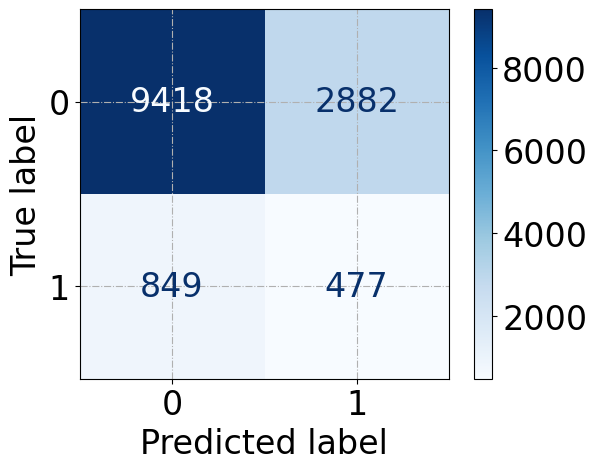

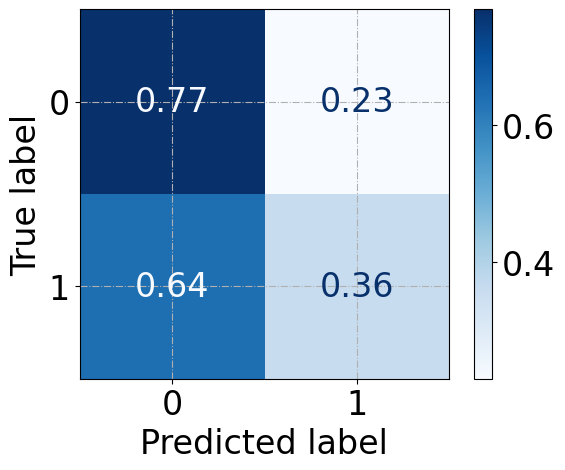

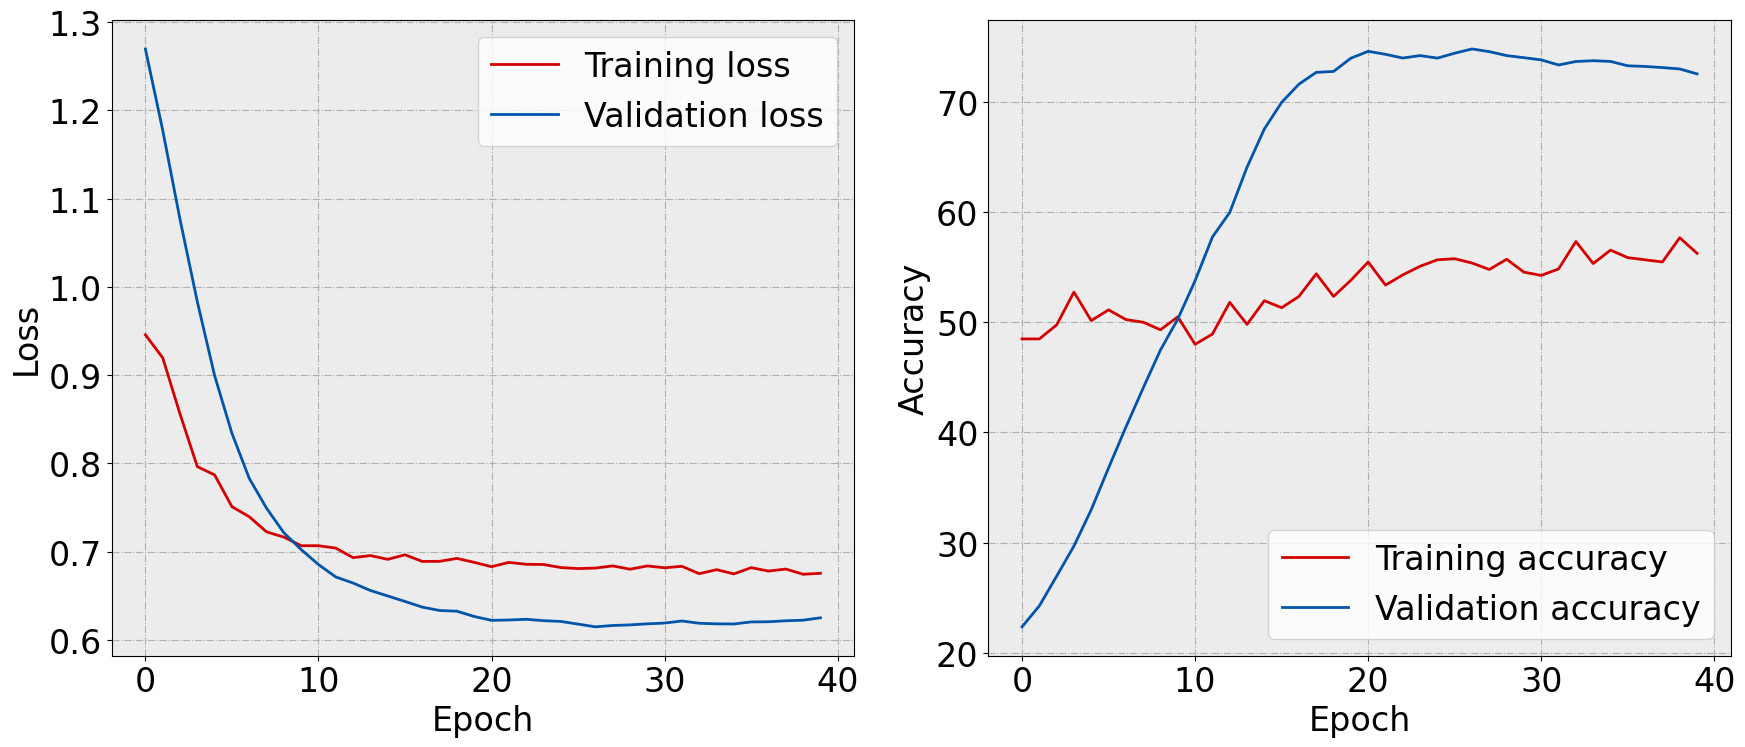

In [19]:
qnn_3_3layers, history_3_3layers, test_loss_3_3layers, test_acc_3_3layers = run_experiment(
        feature_map_name = "fm2",
        ansatz_name = "ansatz1",
        layers = 3,
        n_epochs = 40,
        n_batches = 64,
        batch_size = 32,
        learn_rate = 0.001)